# Analysis of discharge

In [24]:
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
from config import *

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [5]:
# List of possible parameters
parameters = [
    "WTemp_C", "SpC_uScm", "DO_mgL", "pH",
    "Turb_FNU", "Turb_NTU", "NO3_mgNL",
    "fDOM_QSU", "fDOM_RFU", "DOC_mgL",
    "PO4_mgL", "Chla_ugL", "Chla_RFU",
    "PC_ugL", "PC_RFU"
]

In [6]:
# Processing metadata, isolating specific parameters
md_wide = pd.read_csv(metadata_filepath+"metadata.csv", dtype = {'sourceID': str})
print(f"Full dataset size: {md_wide.shape[0]}")
params = ['SpC_uScm','DO_mgL','Turb_FNU']

for param in params:
    md_wide[param] = md_wide['WQ_parameters'].str.contains(param)

# Removing the stations without data
md_wide = md_wide[(md_wide['SpC_uScm']) | (md_wide['DO_mgL']) | (md_wide['Turb_FNU'])]
print(f"Filtered dataset size: {md_wide.shape[0]}")

Full dataset size: 4268
Filtered dataset size: 2688


# Sampling Coverage Across Flow Regime

In [8]:
# Number of bins for the flow distribution (20 bins = 5% increments)
n_bins = 20
bin_edges_pct = np.linspace(0, 1, n_bins + 1)
bin_labels = [f'{int(bin_edges_pct[i]*100)}-{int(bin_edges_pct[i+1]*100)}'
              for i in range(n_bins)]

# Bulding the dataframe
results = []
missing_flow = 0
# Iterate over each row and calculate
for i, row in md_wide.iterrows():
    try:
        site = row['STREAM_ID']
        wq_para_data = pd.read_csv(water_quality_filepath+site+'.csv', low_memory=False)
        q_data  = pd.read_csv(discharge_filepath+site+'.csv', low_memory=False)
        
        # Determine distribution of flow. This should be done with a longer period of record, but for now we will leave it. 
        Q_percentiles = np.quantile(q_data['Q_m3s'].dropna(), bin_edges_pct)
        
        # Identify which parameters are available
        wq_params = [col for col in wq_para_data.columns 
                     if col != 'DateTime' and not col.startswith('Flag_')]
        
        for param in wq_params:
            wq_para_i = wq_para_data[['DateTime', param]].copy()
            wq_para_i.dropna(subset = [param], inplace=True)
            wq_para_i = wq_para_i.merge(q_data, on='DateTime', how='left')
            wq_para_i.dropna(subset=['Q_m3s'], inplace=True)
            
            if wq_para_i.empty:
                continue
            
            # Binning the sample flow based on percentile 
            wq_para_i['bins'] = pd.cut(wq_para_i['Q_m3s'], 
                                       bins=Q_percentiles,
                                       labels=bin_labels,
                                       include_lowest=True,
                                       duplicates='drop')
            
            # Count samples per flow bin
            counts = wq_para_i['bins'].value_counts().reindex(bin_labels, fill_value=0)
            
            result_row = {
                'STREAM_ID': site,
                'param': param,
                'n_samples': int(counts.sum())
            }
            for label in bin_labels:
                result_row[label] = counts[label]
            results.append(result_row)
    except:
        missing_flow+=1  
df_results = results
print(f"Missing flow for {np.round((missing_flow/len(md_wide))*100,1)}% of stations.")

Missing flow for 51.1% of stations.


In [20]:
# Organizing the dataframe
WQ_Q_binned_results = pd.DataFrame(results)
WQ_Q_binned_fractions = WQ_Q_binned_results[bin_labels].div(WQ_Q_binned_results['n_samples'], axis=0)*100

WQ_Q_binned_fractions.insert(0, 'STREAM_ID', WQ_Q_binned_results['STREAM_ID'])
WQ_Q_binned_fractions.insert(1, 'param', WQ_Q_binned_results['param'])
WQ_Q_binned_fractions.insert(2, 'n_samples', WQ_Q_binned_results['n_samples'])

# Expected distribution
expected = 1.0 / n_bins
print(f"The expected distribution if the sampling was evenly distributed is {expected*100}%.")

WQ_Q_binned_fractions.head()

The expected distribution if the sampling was evenly distributed is 5.0%.


,STREAM_ID,param,n_samples,0-5,5-10,10-15,15-20,20-25,25-30,30-35,35-40,40-45,45-50,50-55,55-60,60-65,65-70,70-75,75-80,80-85,85-90,90-95,95-100
0,STREAM-gauge-21,WTemp_C,13977,5.873936,4.085283,3.813408,3.913572,5.473278,6.188739,6.804035,9.300994,7.161766,6.217357,6.174429,6.832654,4.013737,4.493096,4.536023,3.169493,3.248193,3.985118,2.883308,1.831580
1,STREAM-gauge-21,SpC_uScm,12356,6.353189,4.184202,3.795727,3.933312,5.689544,6.094205,6.450308,7.931369,6.312723,6.021366,6.264163,7.300097,4.216575,4.799288,4.742635,3.358692,3.536743,4.346067,3.156361,1.513435
2,STREAM-gauge-21,DO_mgL,9759,7.049903,3.350753,3.986064,4.436930,5.666564,5.820268,6.711753,9.191516,6.773235,5.625576,5.533354,6.998668,3.361000,4.570140,4.447177,3.504457,3.504457,4.764832,3.688903,1.014448
3,STREAM-gauge-21,pH,13149,6.243821,4.220853,3.863412,3.954673,5.696251,6.182980,6.548026,8.936041,7.209674,5.620199,6.152559,7.004335,3.954673,4.403377,4.532664,3.095292,3.353867,4.015514,3.064872,1.946916
4,STREAM-gauge-21,Turb_FNU,7869,8.882958,4.066590,4.193671,4.219088,6.252383,6.735290,8.056932,9.772525,7.205490,5.858432,5.489897,6.938620,3.011819,3.507434,3.659931,2.960986,2.300165,3.621807,2.160376,1.105604


11.24

In [156]:
# Per-solute colorbar layout + label placement
cbar_config = {
    'DO_mgL': {
        'fig_width':   4,
        'fig_height': 10,
        'inset':       [1.025, 0.4, 0.03, 0.2],
        'title_xy':    (0.0, 1.2),
        'subtitle_xy': (0.0, 1.04),
    },
    'SpC_uScm': {
        'fig_width':   4,
        'fig_height': 10,
        'inset':       [1.025, 0.4, 0.03, 0.2],
        'title_xy':    (0.0, 1.2),
        'subtitle_xy': (0.0, 1.04),
    },
    'Turb_FNU': {
        'fig_width':   4,
        'fig_height': 10,
        'inset':       [1.025, 0.4, 0.03, 0.2],
        'title_xy':    (0.0, 1.2),
        'subtitle_xy': (0.0, 1.03),
    },
    'WTemp_C': {
        'fig_width':   4,
        'fig_height': 10,
        'inset':       [1.025, 0.4, 0.03, 0.105],
        'title_xy':    (0.0, 1.2),
        'subtitle_xy': (0.0, 1.04),
    },
    'NO3_mgNL': {
        'fig_width':   4,
        'fig_height': 10,
        'inset':       [1.025, 0.4, 0.03, 0.25],
        'title_xy':    (0.0, 1.15),
        'subtitle_xy': (0.0, 1.04),
    },
}

# Fallback so a missing key doesn't crash the loop
default_cbar_config = {
    'fig_width':   4,
    'fig_height': 15,
    'inset':       [1.025, 0.4, 0.03, 0.105],
    'title_xy':    (0.0, 1.13),
    'subtitle_xy': (0.0, 1.04),
}

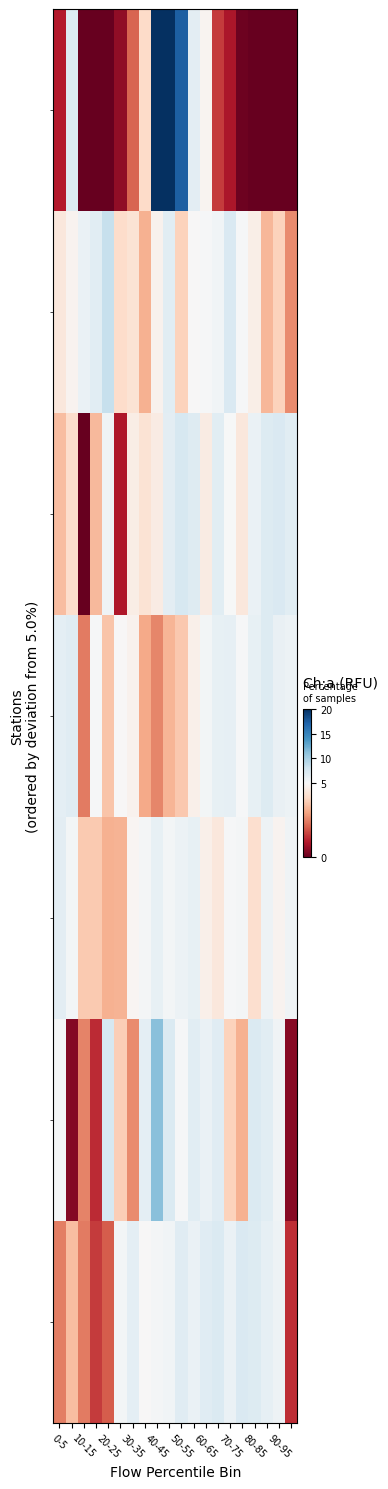

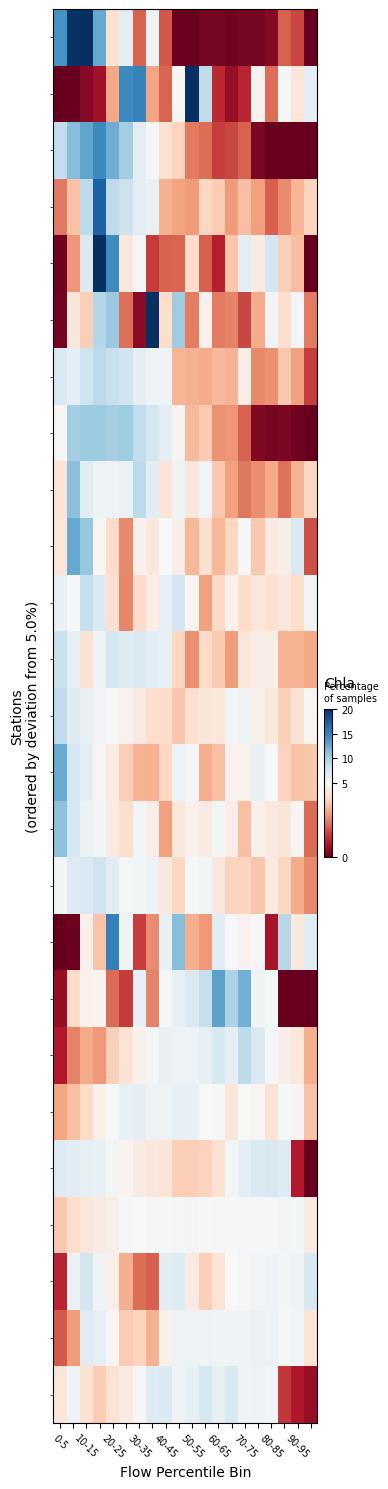

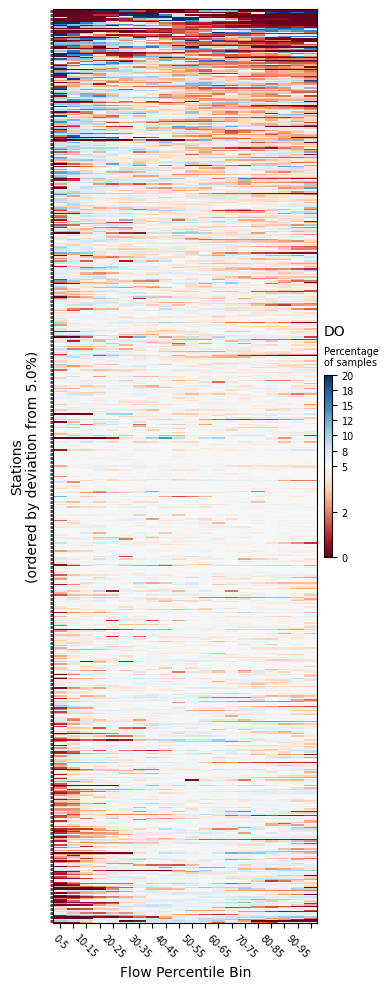

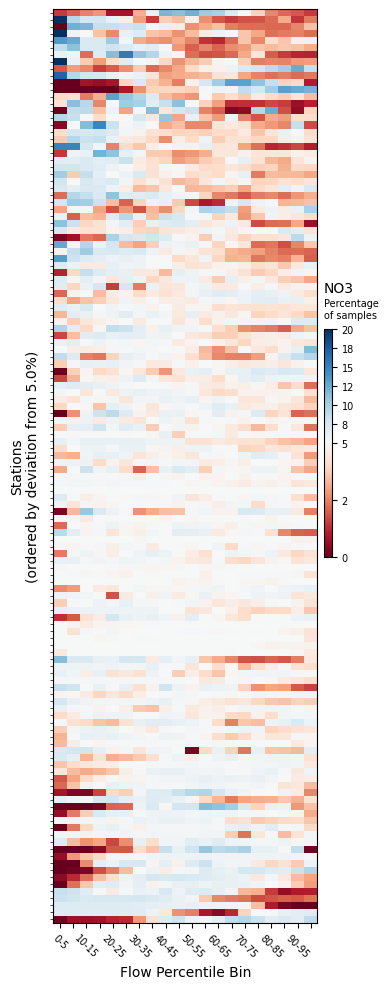

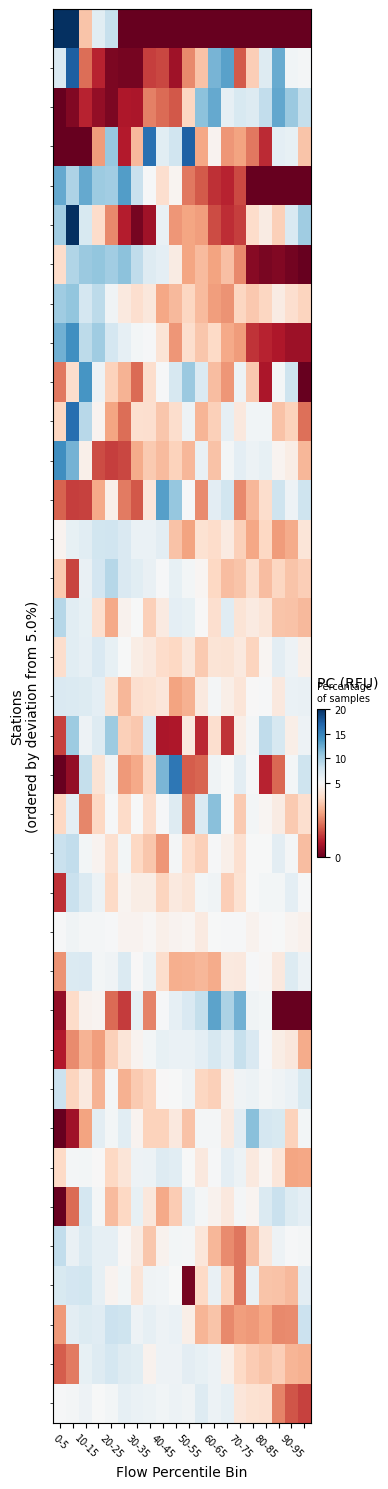

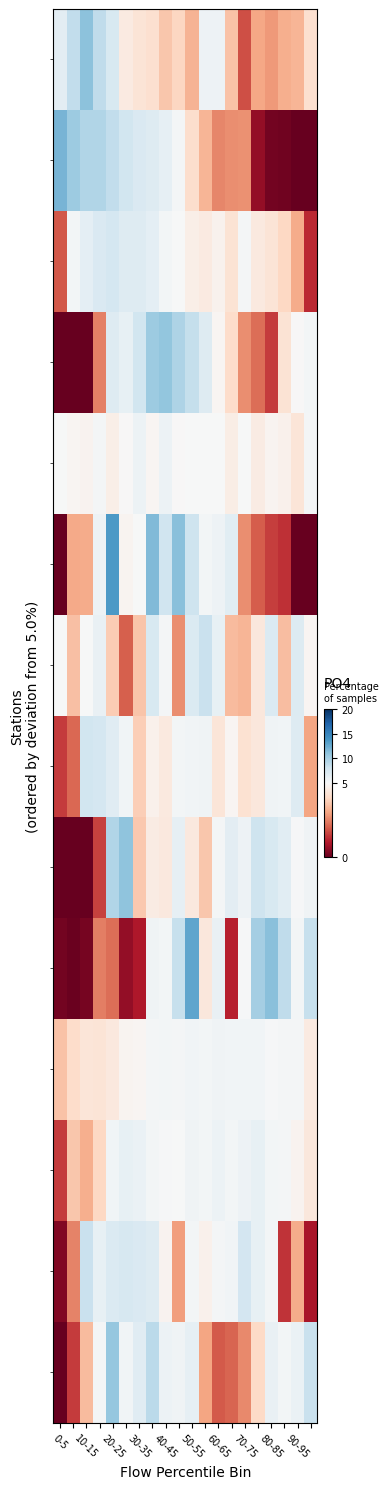

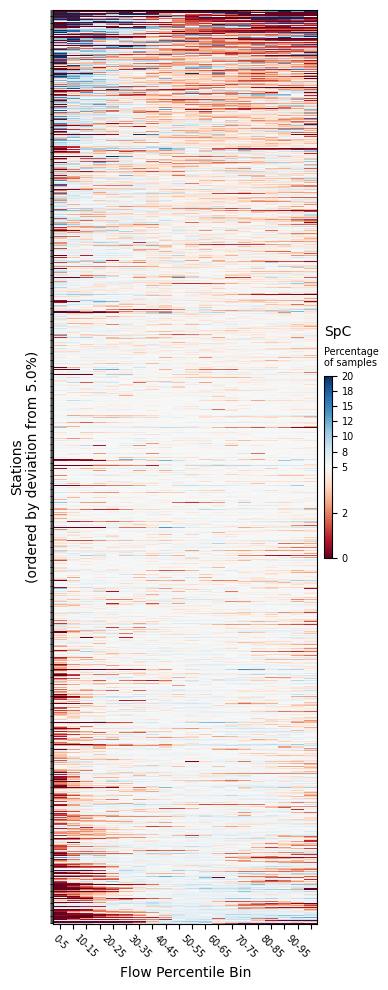

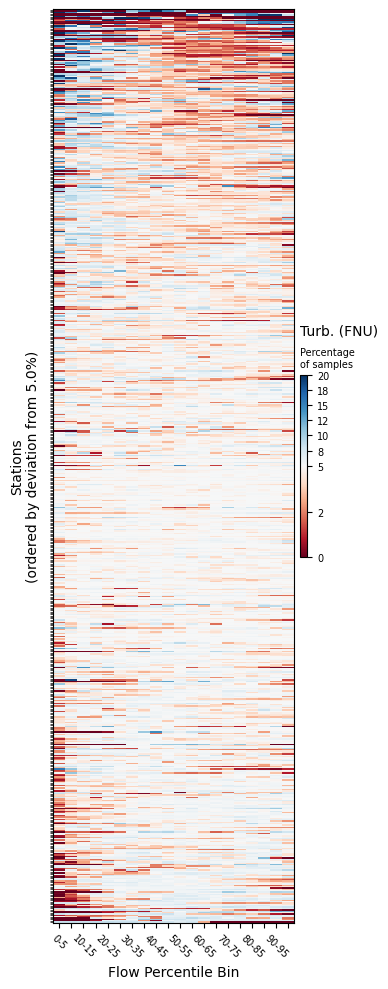

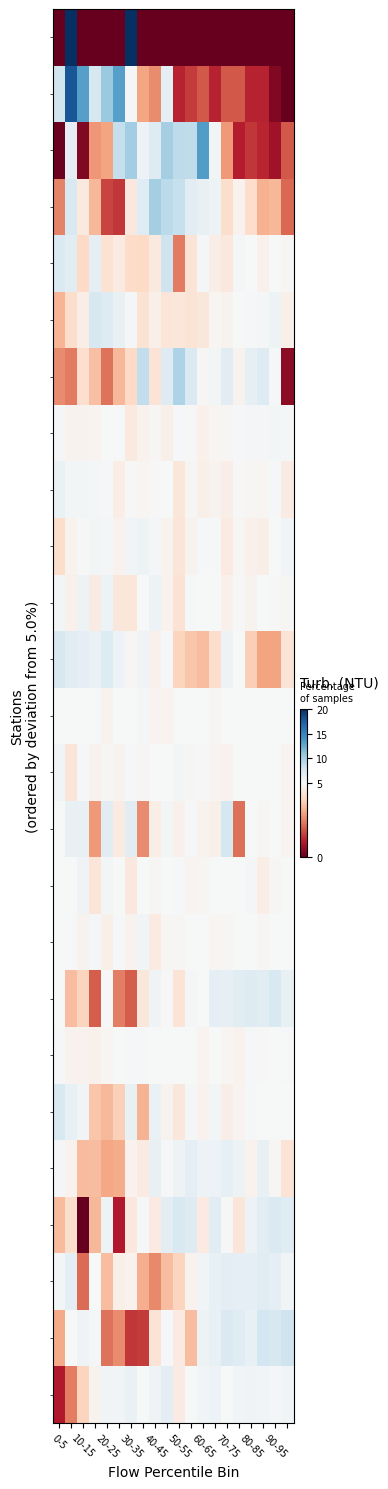

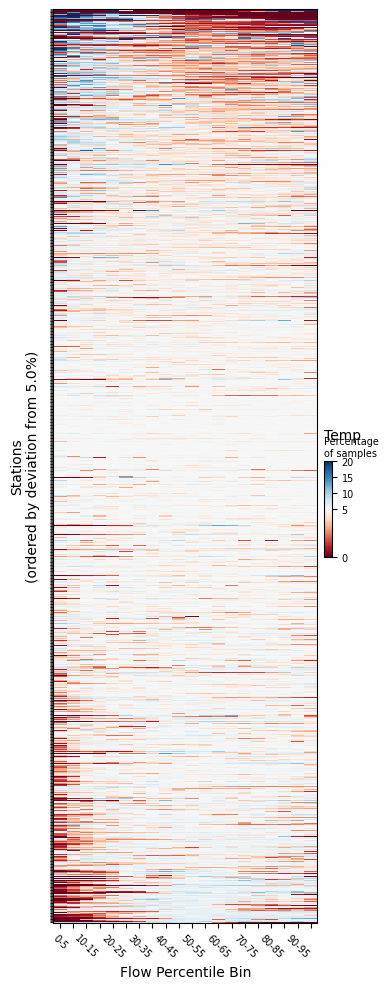

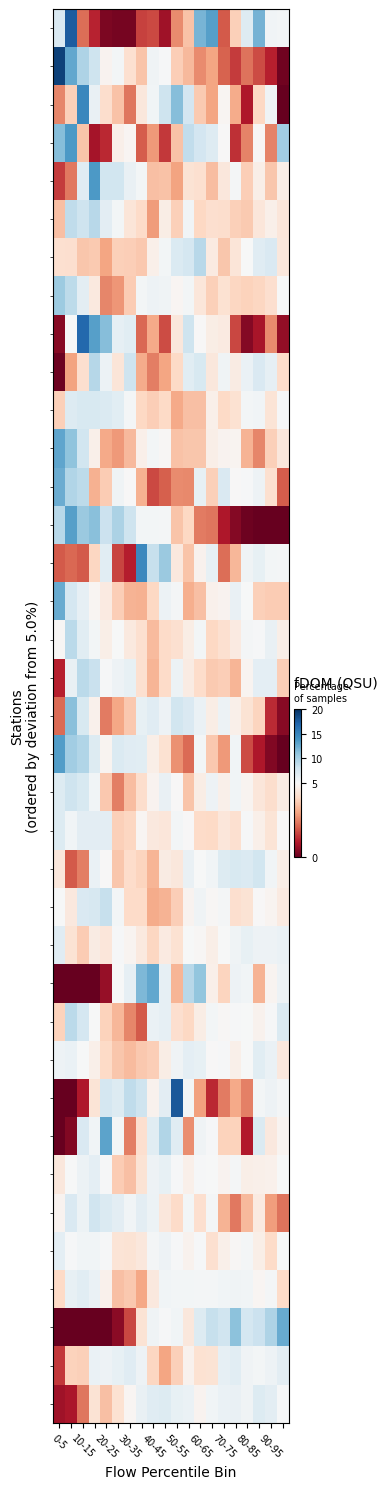

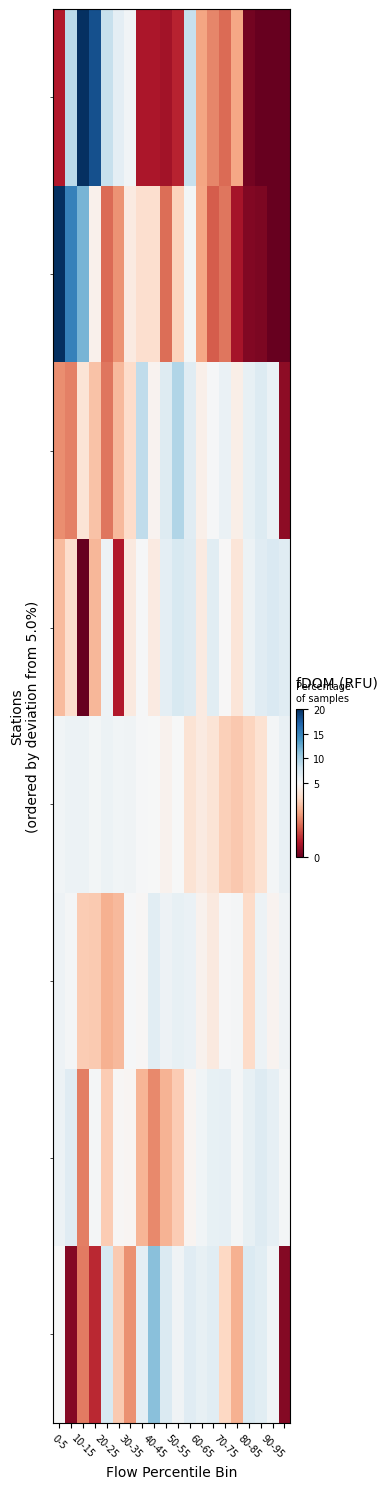

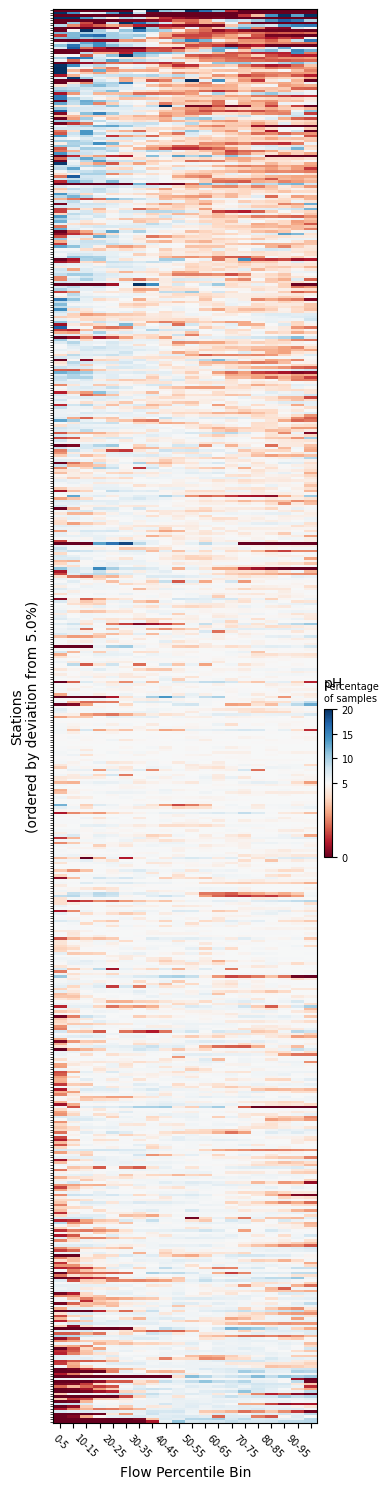

In [157]:
# Create heat map for each solute
params_dict = {'DO_mgL':'DO (mg/L)',
               'SpC_uScm':'SpC (μS/cm)',
               'Turb_FNU':'Turbidity (FNU)'}
solute_summary = []
#WQ_Q_binned_fractions_ss = WQ_Q_binned_fractions[WQ_Q_binned_fractions['param'].isin(params)]
for solute, binned_sol in WQ_Q_binned_fractions.groupby('param'):

    cfg = cbar_config.get(solute, default_cbar_config)
    
    # Currently sorted by STREAM ID (inherent). Uncomment to sort by high-flow sampling coverage.
    binned_sol = binned_sol.copy()
    binned_sol['sort_key'] = (binned_sol[bin_labels] - expected).abs().median(axis=1)
    binned_sol.sort_values('sort_key', ascending=False, inplace=True)
    binned_sol.drop(columns='sort_key', inplace=True)

    # Summary of results
    mid_cols = [l for l in bin_labels if int(l.split('-')[0]) >= 25 and int(l.split('-')[1]) <= 75]
    
    solute_summary_i = {
    'solute': solute,
    'n_sites': len(binned_sol),
    'median_n_samples': binned_sol['n_samples'].median(),
    'pct_below_10p': np.mean(binned_sol['0-5'] + binned_sol['5-10']), # Tail sampling
    'pct_above_90p': np.mean(binned_sol['90-95'] + binned_sol['95-100']), # Tail sampling
    'mean_abs_deviation': (binned_sol[bin_labels] - expected * 100).abs().mean().mean(), # Overall bias (how far from representative is sampling on average?)
    'pct_sites_no_highflow': ((binned_sol['90-95'] + binned_sol['95-100']) == 0).mean() * 100, # What fraction of sites have zero samples in the top 10% of flows?
    'peak_bin': binned_sol[bin_labels].median().idxmax(), # Where does the bulk of sampling concentrate?
    'pct_mid_flow': np.mean(binned_sol[mid_cols].sum(axis=1))  # Middle flow bias (what % of samples sit between 25th-75th percentile?)
    }
    solute_summary.append(solute_summary_i)
    
    # Extrating values
    plot_matrix = binned_sol[bin_labels].values
    site_labels = binned_sol['STREAM_ID'].values

    # Crating heatmap
    fig, ax = plt.subplots(figsize= (cfg['fig_width'], cfg['fig_height'])) #(4,10) max(3, len(site_labels) * 0.02)
    
    vmax = 20 # percent (cbar max range)
    norm = mcolors.TwoSlopeNorm(vmin=0, vcenter=expected*100, vmax=vmax) # setting max, min, and zero place
    
    im = ax.pcolormesh(plot_matrix, cmap='RdBu', norm=norm, edgecolors='none')

    # x axis aesthethic properties
    ax.set_xticks(np.arange(n_bins) + 0.5)
    ax.set_xticklabels([label if i % 2 == 0 else '' for i, label in enumerate(bin_labels)],
                   rotation=360-45, ha='center', fontsize=7)
    ax.set_xlabel('Flow Percentile Bin')

    # y axis aesthethic properties
    ax.set_yticks(np.arange(len(site_labels)) + 0.5)
    ax.set_yticklabels([])
    ax.tick_params(axis='y', length=2, width=0.5)
    ax.set_ylabel(f'Stations\n(ordered by deviation from {round(expected*100,0)}%)')

    # color bar aesthethic properties
    cbax = ax.inset_axes(cfg['inset'], transform=ax.transAxes)
    cbar = fig.colorbar(im, cax=cbax, orientation='vertical')
    cbar.ax.tick_params(labelsize=7)

    tx, ty = cfg['title_xy']
    sx, sy = cfg['subtitle_xy']
    cbax.text(tx, ty, f'{params_pretty_dict[solute]}', fontsize=10,
              ha='left', va='bottom', transform=cbax.transAxes)
    cbax.text(sx, sy, 'Percentage\nof samples', fontsize=7,
              ha='left', va='bottom', transform=cbax.transAxes)
    cbar.ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0f}'))
    
    plt.tight_layout()
    plt.savefig(f'../OUTPUT/temporal_patterns/sampling_bias_heatmap_{solute}.png', dpi=600, bbox_inches='tight')
    #plt.show()

In [150]:
solute_summary_df = pd.DataFrame(solute_summary)
solute_summary_df.to_csv(OUTPUT_filepath+'discharge_statistics.csv', index=False)